<a href="https://colab.research.google.com/github/Tienndat2306/TH_DeepLearning_Tuan4/blob/main/CNN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nạp thư viện

In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

Đọc dữ liệu

In [6]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train. iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [7]:
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255
X_train = X_train. to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test. to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


Trực quan hóa dữ liệu


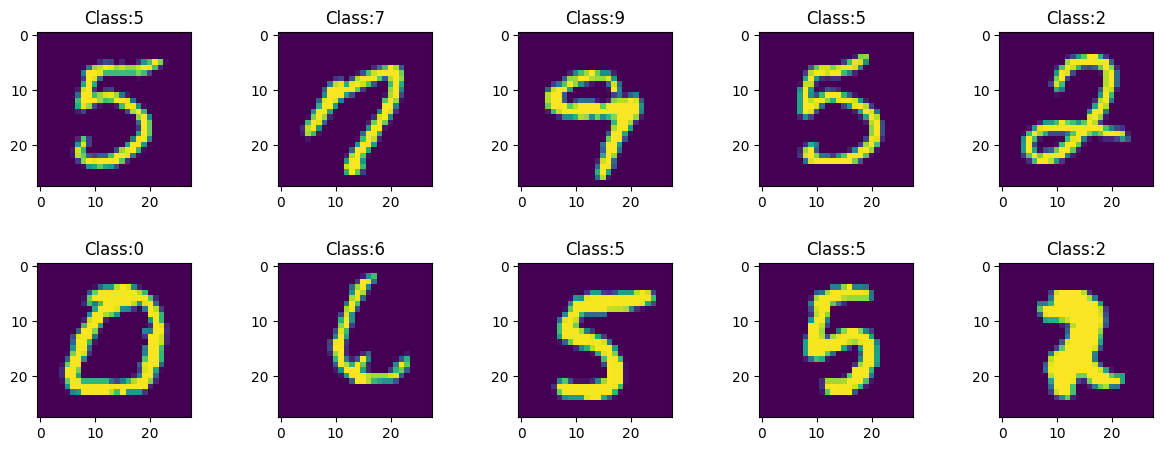

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

One-hot encoding

In [9]:
y_train = keras. utils.to_categorical(y_train, num_classes)
y_test = keras. utils. to_categorical(y_test, num_classes)

Xây dựng mô hình

In [10]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Huấn luyện

In [11]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy' ])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8345 - loss: 0.5985 - val_accuracy: 0.9325 - val_loss: 0.2289
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9550 - loss: 0.1535 - val_accuracy: 0.9585 - val_loss: 0.1353
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9688 - loss: 0.1040 - val_accuracy: 0.9685 - val_loss: 0.1039
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9760 - loss: 0.0794 - val_accuracy: 0.9700 - val_loss: 0.0919
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9797 - loss: 0.0658 - val_accuracy: 0.9720 - val_loss: 0.0876
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9828 - loss: 0.0562 - val_accuracy: 0.9750 - val_loss: 0.0738
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9854 - loss: 0.0474 - val_accuracy: 0.9780 - val_loss: 0.0736
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9873 - loss: 0.0417 - val_accuracy: 

Đánh giá mô hình

Accuracy

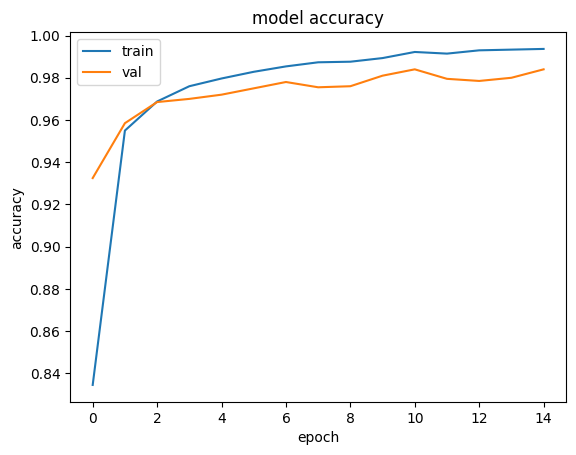

In [12]:
plt.plot(model_fit.history['accuracy' ])
plt.plot(model_fit.history['val_accuracy' ])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Loss

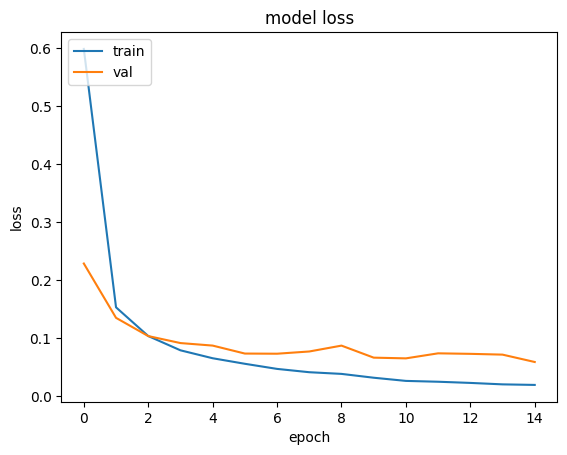

In [14]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss' ])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Thử nghiệm trên tập test

In [15]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 6ms/step - accuracy: 0.9844 - loss: 0.0523
Test loss: 0.05230563506484032
Test accuracy: 0.9843984246253967


Dự báo nhãn cho ảnh

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
[[6.6094649e-06 1.9767108e-04 9.9979568e-01 1.5539952e-09 9.1320578e-20
  1.3638052e-13 5.3149833e-08 6.1375121e-17 1.1745777e-09 2.2804457e-19]]
2 2


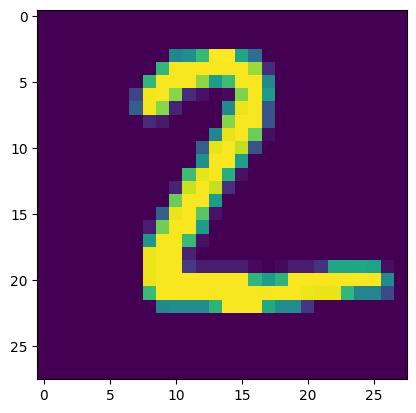

In [18]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

Upload hình ảnh và kiểm tra

Saving 1.png to 1.png


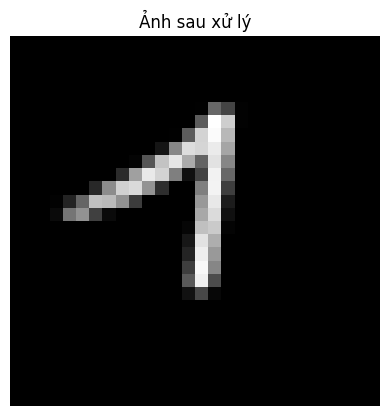

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

========== KẾT QUẢ DỰ ĐOÁN ==========
File ảnh: 1.png
Class dự đoán: 1
Độ tin cậy: 59.08%

Xác suất từng class:
Class 0: 0.00%
Class 1: 59.08%
Class 2: 6.50%
Class 3: 11.33%
Class 4: 0.09%
Class 5: 0.00%
Class 6: 0.00%
Class 7: 13.02%
Class 8: 0.00%
Class 9: 9.97%


In [19]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


uploaded = files.upload()

for file_name in uploaded.keys():

    img = Image.open(file_name).convert("L")

    img = img.resize((28, 28))

    img_array = np.array(img)

    img_array = 255 - img_array

    img_array = img_array.astype("float32") / 255.0

    plt.imshow(img_array, cmap="gray")
    plt.title("Ảnh sau xử lý")
    plt.axis("off")
    plt.show()

    img_input = img_array.reshape(1, 28, 28, 1)

    prediction = model.predict(img_input)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    print("\n========== KẾT QUẢ DỰ ĐOÁN ==========")
    print("File ảnh:", file_name)
    print("Class dự đoán:", predicted_class)
    print(f"Độ tin cậy: {confidence:.2f}%")

    print("\nXác suất từng class:")
    for i, prob in enumerate(prediction[0]):
        print(f"Class {i}: {prob * 100:.2f}%")

Lưu tham số mô hình

In [ ]:
model.save_weights('cnn.h5')

Nạp lại mô hình và tham số

In [ ]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()